In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import os
import glob

# === 1. LOAD AND CONCATENATE MULTIPLE CSV FILES ===
data_folder = "archive (3)/har70plus"  # change to your actual folder path
all_files = glob.glob(os.path.join(data_folder, "*.csv"))

df_list = []
for file in all_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

# === CLEAN DATA ===
df.dropna(inplace=True)

# Drop 'timestamp' and 'label' for feature processing
print("Columns:", df.columns)

if 'timestamp' in df.columns:
    features = df.drop(['label', 'timestamp'], axis=1).values
else:
    features = df.drop(['label'], axis=1).values

# Standardize features
scaler = StandardScaler()
features = scaler.fit_transform(features)

# === 2. SEGMENT TIME-SERIES INTO WINDOWS ===
def create_segments(data, labels, window_size=100, step=50):
    segments = []
    segment_labels = []
    for i in range(0, len(data) - window_size, step):
        segment = data[i:i + window_size]
        label = labels[i + window_size - 1]  # Label from the end of the window
        segments.append(segment)
        segment_labels.append(label)
    return np.array(segments), np.array(segment_labels)

# Label encode to ensure zero-based integer classes
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(df['label'].values)

segments, segment_labels = create_segments(features, labels)

# === 3. SPLIT DATASET ===
X_train, X_test, y_train, y_test = train_test_split(
    segments, segment_labels, test_size=0.2, random_state=42
)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# Create DataLoaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32)

# === 4. DEFINE TRANSFORMER MODEL ===
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, model_dim=64, num_heads=4, num_layers=2, num_classes=2):
        super(TimeSeriesTransformer, self).__init__()
        self.embedding = nn.Linear(input_dim, model_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(model_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)              # (batch, seq, model_dim)
        x = x.permute(1, 0, 2)             # (seq, batch, model_dim)
        x = self.transformer_encoder(x)    # (seq, batch, model_dim)
        x = x.mean(dim=0)                  # (batch, model_dim)
        return self.classifier(x)

# Detect input and output dimensions
input_dim = X_train.shape[2]
num_classes = len(np.unique(y_train.numpy()))
print("Detected number of classes:", num_classes)

# Initialize model
model = TimeSeriesTransformer(input_dim=input_dim, num_classes=num_classes)

# === 5. TRAINING ===
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    model.train()
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/10], Loss: {avg_loss:.4f}")

# === 6. EVALUATION ===
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

# === FIX: Ensure string class names in classification report ===
print("Accuracy:", accuracy_score(all_labels, all_preds))
print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))
print("Classification Report:\n", classification_report(
    all_labels, all_preds, target_names=[str(c) for c in label_encoder.classes_]
))



Columns: Index(['timestamp', 'back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y',
       'thigh_z', 'label'],
      dtype='object')
Detected number of classes: 7


c:\Users\JARE WORKS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch [1/10], Loss: 0.2668
Epoch [2/10], Loss: 0.2255
Epoch [3/10], Loss: 0.2060
Epoch [4/10], Loss: 0.2000
Epoch [5/10], Loss: 0.1903
Epoch [6/10], Loss: 0.1896
Epoch [7/10], Loss: 0.1789
Epoch [8/10], Loss: 0.1783
Epoch [9/10], Loss: 0.1776
Epoch [10/10], Loss: 0.1705
Accuracy: 0.9327284797521576
Confusion Matrix:
 [[4218    4    0    0  165    5    0]
 [  94   10    0    0  171    2    0]
 [   6    0   12    1    1    0    0]
 [   7    0    0    9    4    0    0]
 [ 100    2    0    0 1562    3    0]
 [   3    0    0    0    1 1853    2]
 [   6    0    0    0    2   29  766]]
Classification Report:
               precision    recall  f1-score   support

           1       0.95      0.96      0.96      4392
           3       0.62      0.04      0.07       277
           4       1.00      0.60      0.75        20
           5       0.90      0.45      0.60        20
           6       0.82      0.94      0.87      1667
           7       0.98      1.00      0.99      1859
           

c:\Users\JARE WORKS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch [1/25] Train Loss: 0.2732, Val Loss: 0.2356, Train Acc: 91.37%, Val Acc: 92.16%
Epoch [2/25] Train Loss: 0.2305, Val Loss: 0.2078, Train Acc: 92.38%, Val Acc: 93.17%
Epoch [3/25] Train Loss: 0.2108, Val Loss: 0.2016, Train Acc: 92.75%, Val Acc: 93.47%
Epoch [4/25] Train Loss: 0.1977, Val Loss: 0.1846, Train Acc: 93.08%, Val Acc: 93.15%
Epoch [5/25] Train Loss: 0.1862, Val Loss: 0.1894, Train Acc: 93.25%, Val Acc: 93.56%
Epoch [6/25] Train Loss: 0.1816, Val Loss: 0.1767, Train Acc: 93.45%, Val Acc: 93.76%
Epoch [7/25] Train Loss: 0.1756, Val Loss: 0.2030, Train Acc: 93.59%, Val Acc: 93.11%
Epoch [8/25] Train Loss: 0.1760, Val Loss: 0.1815, Train Acc: 93.54%, Val Acc: 93.69%
Epoch [9/25] Train Loss: 0.1699, Val Loss: 0.1714, Train Acc: 93.69%, Val Acc: 93.83%
Epoch [10/25] Train Loss: 0.1631, Val Loss: 0.1764, Train Acc: 93.82%, Val Acc: 93.62%
Epoch [11/25] Train Loss: 0.1713, Val Loss: 0.1759, Train Acc: 93.63%, Val Acc: 93.75%
Epoch [12/25] Train Loss: 0.1625, Val Loss: 0.1718, 

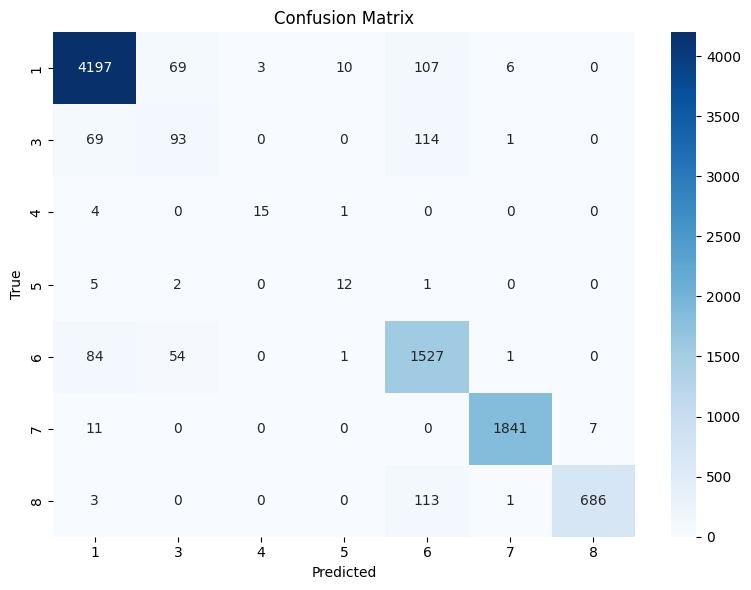

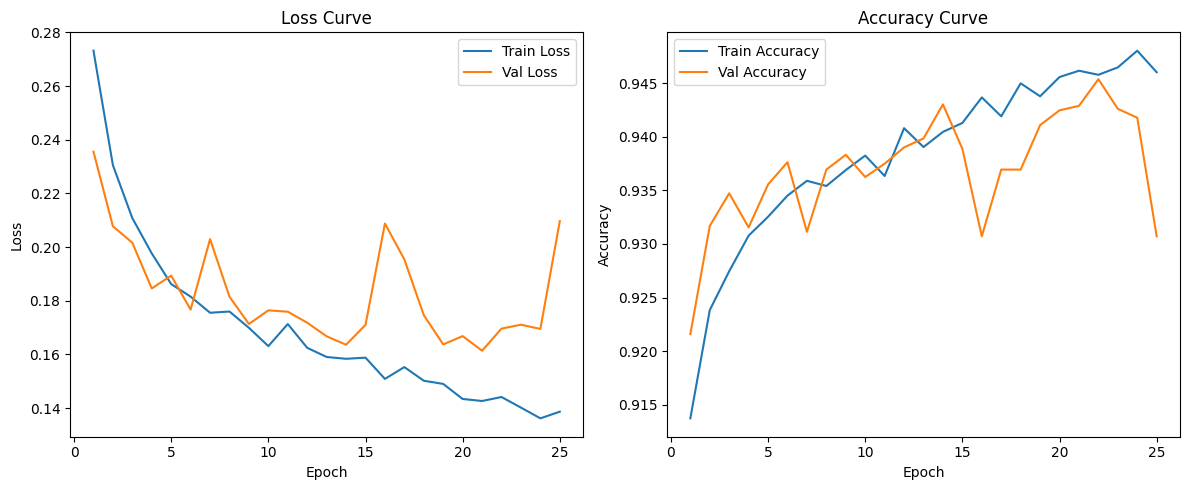

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import os
import glob

# === 1. LOAD AND CONCATENATE MULTIPLE CSV FILES ===
data_folder = "archive (3)/har70plus"
all_files = glob.glob(os.path.join(data_folder, "*.csv"))

df_list = []
for file in all_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
df.dropna(inplace=True)

if 'timestamp' in df.columns:
    features = df.drop(['label', 'timestamp'], axis=1).values
else:
    features = df.drop(['label'], axis=1).values

scaler = StandardScaler()
features = scaler.fit_transform(features)

# === 2. SEGMENT TIME-SERIES INTO WINDOWS ===
def create_segments(data, labels, window_size=100, step=50):
    segments = []
    segment_labels = []
    for i in range(0, len(data) - window_size, step):
        segment = data[i:i + window_size]
        label = labels[i + window_size - 1]
        segments.append(segment)
        segment_labels.append(label)
    return np.array(segments), np.array(segment_labels)

label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(df['label'].values)
segments, segment_labels = create_segments(features, labels)

# === 3. SPLIT DATASET ===
X_train_full, X_test, y_train_full, y_test = train_test_split(
    segments, segment_labels, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32)

# === 4. MODEL ===
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, model_dim=64, num_heads=4, num_layers=2, num_classes=2):
        super(TimeSeriesTransformer, self).__init__()
        self.embedding = nn.Linear(input_dim, model_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(model_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(1, 0, 2)
        x = self.transformer_encoder(x)
        x = x.mean(dim=0)
        return self.classifier(x)

input_dim = X_train.shape[2]
num_classes = len(np.unique(y_train.numpy()))
model = TimeSeriesTransformer(input_dim=input_dim, num_classes=num_classes)

# === 5. TRAINING WITH VALIDATION LOOP ===
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(25):  # Change to 50+ for longer training
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(correct / total)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_correct += (predicted == batch_y).sum().item()
            val_total += batch_y.size(0)
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_correct / val_total)

    print(f"Epoch [{epoch+1}/25] "
          f"Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, "
          f"Train Acc: {train_accuracies[-1]*100:.2f}%, Val Acc: {val_accuracies[-1]*100:.2f}%")

# === 6. TEST EVALUATION ===
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

print("\n=== Final Evaluation ===")
print("Accuracy:", accuracy_score(all_labels, all_preds))
print("Classification Report:\n", classification_report(
    all_labels, all_preds, target_names=[str(c) for c in label_encoder.classes_]
))

# === 7. GRAPHICAL CONFUSION MATRIX ===
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# === 8. TRAINING CURVES ===
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()
